In [7]:

import gymnasium as gym
import numpy as np
np.random.seed(42)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import text_flappy_bird_gym

from agents import MonteCarloAgent, SarsaLambdaAgent
cm = sns.color_palette("blend:white,green", as_cmap=True)


In [2]:
def plot_q_table_heatmap(q_tables, titles=None):
    num_agents = len(q_tables)
    rows = (num_agents + 1) // 2
    cols = 2 if num_agents > 1 else 1
    
    fig, axs = plt.subplots(rows, cols, figsize=(14, 6 * rows))
    
    if num_agents == 1:
        axs = np.array([axs])
    axs_flat = axs.flatten()

    for i, q_table in enumerate(q_tables):
        data = []
        for state, actions in q_table.items():
            dx, dy = state
            v_s = np.max(actions) # State-Value V(s)
            data.append({'dx': dx, 'dy': dy, 'Value': v_s})
        
        df = pd.DataFrame(data)
        pivot_table = df.pivot(index='dy', columns='dx', values='Value')
    
        ax = axs_flat[i]
        sns.heatmap(pivot_table, cmap="viridis", ax=ax, 
                    cbar_kws={'label': 'Max Expected Reward (V)'})
        
        agent_title = titles[i] if titles else f"Agent {i+1}"
        ax.set_title(f"{agent_title}: State-Value Function")
        ax.set_xlabel("Horizontal Distance to Gap (dx)")
        ax.set_ylabel("Vertical Distance to Gap (dy)")
        ax.invert_yaxis()

    for j in range(i + 1, len(axs_flat)):
        axs_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

In [8]:
# initiate environment
env = gym.make('TextFlappyBird-v0', height = 15, width = 20, pipe_gap = 4)

#### Env screen comparison

In [6]:
env_screen = gym.make('TextFlappyBird-screen-v0', height = 15, width = 20, pipe_gap = 4)

NameNotFound: Environment `TextFlappyBird-screen` doesn't exist.

In [ ]:
env.reset()

((13, -4),
 {'score': 0, 'player': [6, 7], 'distance': np.float64(13.601470508735444)})

In [14]:
env_screen.reset()

(array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0

In [11]:
env.step(0)

((6, 3),
 1,
 True,
 False,
 {'score': 52, 'player': [6, 15], 'distance': np.float64(6.708203932499369)})

In [15]:
env_screen.step(0)

(array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [2

#### MC Agent

In [9]:
mc_agent = MonteCarloAgent(
    epsilon = 0.1,
    gamma = 0.99
)
n_episodes = 2000

mc_agent.train(env, n_episodes)
mc_eval=mc_agent.evaluate_agent(env, num_tries=100, max_steps=10000,epsilon_greedy=False)
mc_eval.describe()

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 63.35it/s]


,steps,total_scores
count,100.000000,100.00000
mean,2473.500000,246.45000
std,2553.651715,255.35471
min,52.000000,4.00000
25%,688.500000,68.25000
50%,1342.500000,133.50000
75%,3539.500000,352.75000
max,10000.000000,999.00000


##### Tuning

In [4]:
gs = [0.1, 0.5, 0.9]
mc_ags = []
results=[]
n_episodes = 2000

for g in gs:
    mc_agent = MonteCarloAgent(
        epsilon = 0.1,
        gamma = g
    )
    mc_agent.train(env, n_episodes)
    mc_ags.append(mc_agent)
    df = mc_agent.evaluate_agent(env, 100, 10000)
    results.append({
        'gamma': g,
        'avg_time_alive': df['steps'].mean(),
        'avg_score': df['total_scores'].mean()
    })
pd.DataFrame(results)

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:07<00:00, 13.85it/s]


,gamma,avg_time_alive,avg_score
0,0.1,107.54,9.46
1,0.5,854.00,84.19
2,0.9,10000.00,999.00


##### Viz

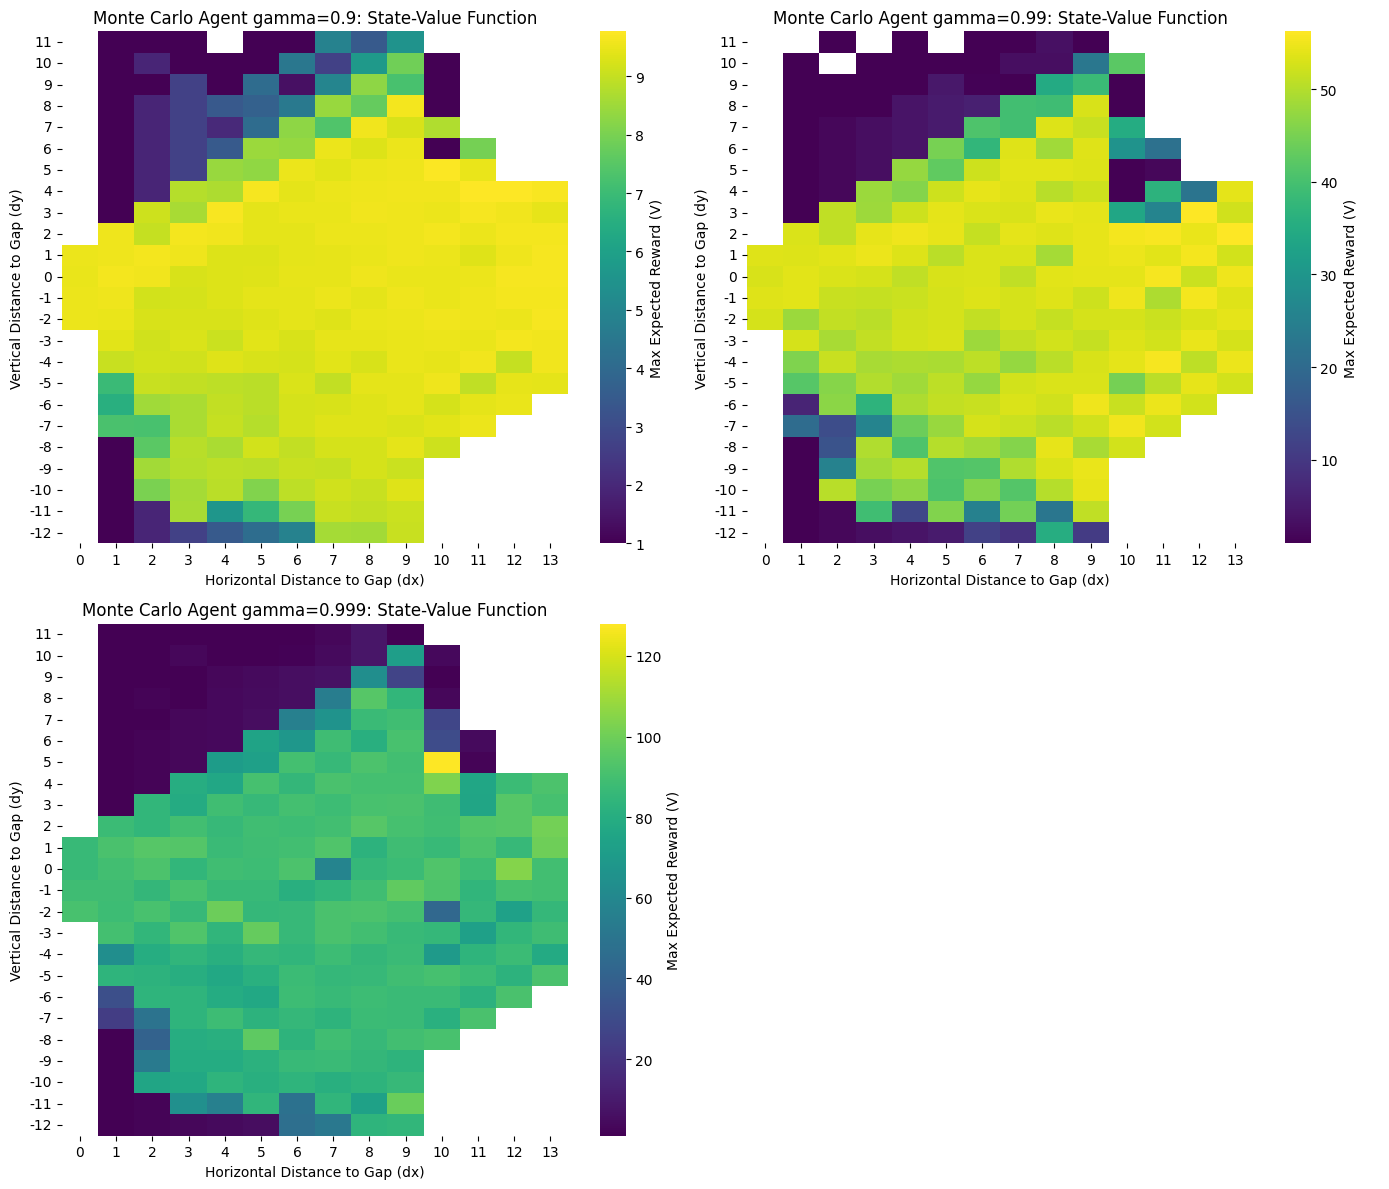

In [ ]:
plot_q_table_heatmap([ag.q_table for ag in ags], 
                     titles=[
                         f"Monte Carlo Agent gamma={g}" for g in gs
                         ]
                     )

In [10]:
mc_agent.visualize_agent(env, max_steps=2000)

Text Flappy Bird!
Score: 132
----------------------
[|         |         ]
[|         |         ]
[|                   ]
[|                   ]
[|                   ]
[|                   ]
[|         |         ]
[|         |         ]
[|         |         ]
[|         |         ]
[          |         ]
[          |         ]
[          |         ]
[          |         ]
[|    *    |         ]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Idle)
Distance From Pipe (dx=4,dy=11)

Step: 1328 | Score: 132


#### Sarsa Agent

In [9]:
sarsa_agent = SarsaLambdaAgent(
    alpha = 0.33,
    gamma = 0.66,
    lmbda = 0.4,
    epsilon = 0.1
)
n_episodes = 10000

sarsa_agent.train(env, n_episodes)
sarsa_eval = sarsa_agent.evaluate_agent(env, num_tries=100, max_steps=10000)
sarsa_eval.describe()

100%|██████████| 100/100 [00:00<00:00, 384.04it/s]


,steps,total_scores
count,100.000000,100.000000
mean,363.400000,35.690000
std,375.128449,37.508435
min,15.000000,1.000000
25%,88.250000,8.000000
50%,246.000000,24.000000
75%,480.750000,47.250000
max,1889.000000,188.000000


array([[<Axes: title={'center': 'steps'}>,
        <Axes: title={'center': 'total_scores'}>]], dtype=object)

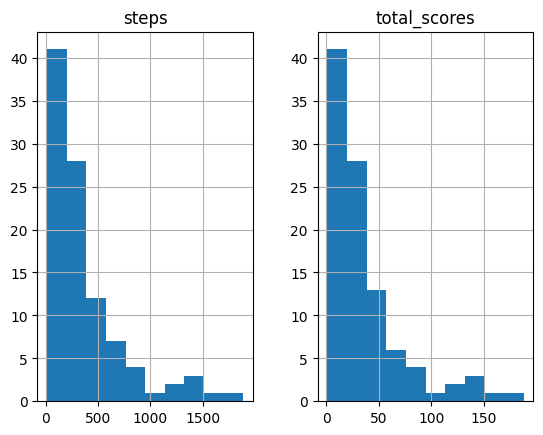

In [10]:
sarsa_eval.hist()

##### Tuning

In [68]:
alpha_space = [
   0.1,
   0.4,
   0.6, 
   # 0.6, 
   # 0.7, 
   # 0.8, 
   0.9
   ]
gamma_space = [
    0.5,
    0.7,
    0.9
    ]
lambda_space = [
   # 0.1, 
   # 0.2, 
   # 0.3, 
   # 0.4, 
   0.5,
   0.6,
   0.7,
   # 0.9
   ]
alpha_space=np.linspace(0.1, 0.9, num=4)
gamma_space=np.linspace(0.1, 1, num=4)
lambda_space=np.linspace(0.1, 1, num=4)
df_results, sarsa_ags = sarsa_agent.grid_search_sarsa(env, alpha_space, lambda_space, gamma_space, episodes=7000)
df_results.sort_values(by=['avg_time_alive', 'avg_score']).style.background_gradient(cmap = cm,axis=0)

100%|██████████| 64/64 [17:51<00:00, 16.75s/it]


,alpha,lambda,gamma,avg_time_alive,avg_score
4,0.100000,0.400000,0.100000,4.780000,0.000000
8,0.100000,0.700000,0.100000,4.885750,0.000000
12,0.100000,1.000000,0.100000,5.146000,0.000000
0,0.100000,0.100000,0.100000,5.313750,0.000000
1,0.100000,0.100000,0.400000,6.918500,0.000000
5,0.100000,0.400000,0.400000,7.461500,0.000000
11,0.100000,0.700000,1.000000,8.553250,0.000000
7,0.100000,0.400000,1.000000,9.076000,0.000000
9,0.100000,0.700000,0.400000,9.454500,0.000000
63,0.900000,1.000000,1.000000,10.387250,0.000000


##### Viz

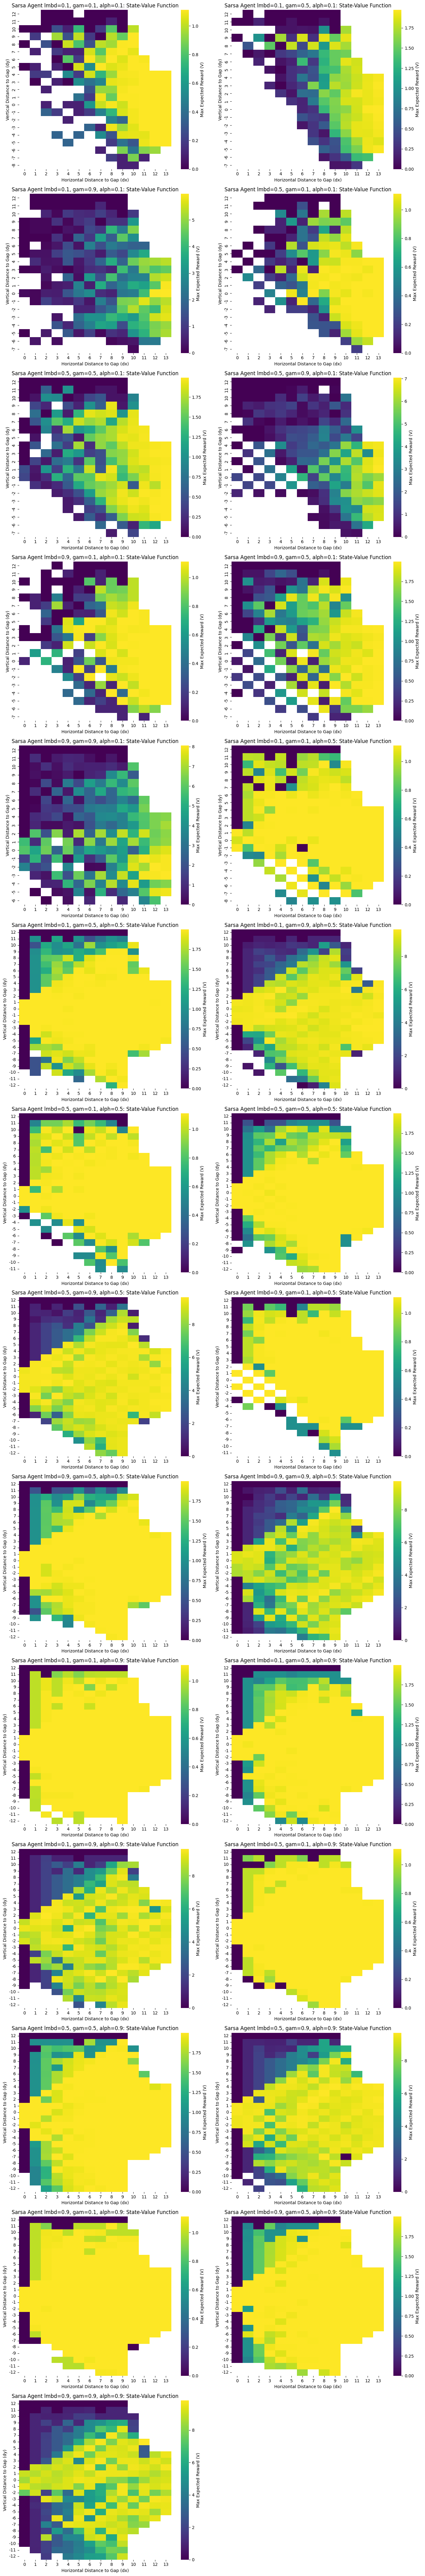

In [16]:
plot_q_table_heatmap([ag.q_table for ag in sarsa_ags.values()], 
                     titles=[f'Sarsa Agent lmbd={lmbda}, gam={gamma}, alph={alpha}'for (alpha, lmbda, gamma), ag in sarsa_ags.items()])

In [9]:
sarsa_agent.visualize_agent(env, max_steps=1000)

Text Flappy Bird!
Score: 2
----------------------
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[                    ]
[                    ]
[                    ]
[                    ]
[         |          ]
[         |          ]
[         |          ]
[     *   |          ]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Idle)
Distance From Pipe (dx=3,dy=6)

Step: 29 | Score: 2


### Change env

#### Change pipe_gap

In [ ]:
mc_eval=mc_agent.evaluate_agent(gym.make('TextFlappyBird-v0', height = 15, width = 20, pipe_gap = 2), num_tries=100, max_steps=10000,epsilon_greedy=False)
mc_eval.describe()

100%|██████████| 100/100 [00:00<00:00, 4425.77it/s]


,steps,total_scores
count,100.00000,100.00000
mean,28.18000,1.62000
std,19.04295,1.81898
min,4.00000,0.00000
25%,13.00000,0.00000
50%,23.00000,1.00000
75%,33.00000,2.00000
max,93.00000,8.00000


In [45]:
mc_eval=mc_agent.evaluate_agent(gym.make('TextFlappyBird-v0', height = 15, width = 20, pipe_gap = 4), num_tries=100, max_steps=10000,epsilon_greedy=False)
mc_eval.describe()

100%|██████████| 100/100 [00:06<00:00, 15.36it/s]


,steps,total_scores
count,100.0,100.0
mean,10000.0,999.0
std,0.0,0.0
min,10000.0,999.0
25%,10000.0,999.0
50%,10000.0,999.0
75%,10000.0,999.0
max,10000.0,999.0


In [46]:
mc_eval=mc_agent.evaluate_agent(gym.make('TextFlappyBird-v0', height = 15, width = 20, pipe_gap = 6), num_tries=100, max_steps=10000,epsilon_greedy=False)
mc_eval.describe()

100%|██████████| 100/100 [00:06<00:00, 15.58it/s]


,steps,total_scores
count,100.0,100.0
mean,10000.0,999.0
std,0.0,0.0
min,10000.0,999.0
25%,10000.0,999.0
50%,10000.0,999.0
75%,10000.0,999.0
max,10000.0,999.0


#### Change height

In [62]:
mc_eval=mc_agent.evaluate_agent(gym.make('TextFlappyBird-v0', height = 8, width = 20, pipe_gap = 4), num_tries=100, max_steps=10000,epsilon_greedy=False)
mc_eval.describe()

100%|██████████| 100/100 [00:06<00:00, 15.60it/s]


,steps,total_scores
count,100.0,100.0
mean,10000.0,999.0
std,0.0,0.0
min,10000.0,999.0
25%,10000.0,999.0
50%,10000.0,999.0
75%,10000.0,999.0
max,10000.0,999.0


In [65]:
mc_eval=mc_agent.evaluate_agent(gym.make('TextFlappyBird-v0', height = 20, width = 20, pipe_gap = 4), num_tries=100, max_steps=10000,epsilon_greedy=False)
mc_eval.describe()

100%|██████████| 100/100 [00:00<00:00, 861.78it/s]


,steps,total_scores
count,100.00000,100.000000
mean,157.25000,14.820000
std,136.55327,13.604352
min,4.00000,0.000000
25%,50.00000,4.000000
50%,119.00000,11.000000
75%,219.25000,21.000000
max,713.00000,70.000000


#### Change width

In [67]:
mc_eval=mc_agent.evaluate_agent(gym.make('TextFlappyBird-v0', height = 15, width = 10, pipe_gap = 4), num_tries=100, max_steps=10000,epsilon_greedy=False)
mc_eval.describe()

100%|██████████| 100/100 [00:00<00:00, 1349.15it/s]


,steps,total_scores
count,100.000000,100.00000
mean,102.690000,19.35000
std,94.328643,18.86388
min,11.000000,1.00000
25%,34.750000,5.75000
50%,76.000000,14.00000
75%,128.500000,24.50000
max,466.000000,92.00000


In [66]:
mc_eval=mc_agent.evaluate_agent(gym.make('TextFlappyBird-v0', height = 15, width = 30, pipe_gap = 4), num_tries=100, max_steps=10000,epsilon_greedy=False)
mc_eval.describe()

100%|██████████| 100/100 [00:00<00:00, 26660.97it/s]


,steps,total_scores
count,100.0,100.0
mean,4.0,0.0
std,0.0,0.0
min,4.0,0.0
25%,4.0,0.0
50%,4.0,0.0
75%,4.0,0.0
max,4.0,0.0
